In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap
from WBUtiles.WBLatex import make_lookup_latex, make_summary_latex

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
inequality = pd.read_csv('../data/Zambia_Inequality/inequality.csv')

In [3]:
inequality_clean, inequality_lookup = clean_wb_wide(inequality, drop_top_rows=0)

In [4]:
print(
    make_lookup_latex(inequality_lookup,
                      caption='World Bank indicators used in Inequality (Zambia)',
                      label='tab:inequality_indicator_list')
)

\begin{table}
\caption{World Bank indicators used in Inequality (Zambia)}
\label{tab:inequality_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
SI.POV.GINI & Gini index \\
SI.POV.NAHC & Poverty headcount ratio at national poverty lines (\% of population) \\
SI.POV.SOPO & Poverty headcount ratio at societal poverty line (\% of population) \\
SI.POV.UMIC & Poverty headcount ratio at \$8.30 a day (2021 PPP) (\% of population) \\
SI.POV.LMIC & Poverty headcount ratio at \$4.20 a day (2021 PPP) (\% of population) \\
SI.POV.DDAY & Poverty headcount ratio at \$3.00 a day (2021 PPP) (\% of population) \\
SE.ENR.TERT.FM.ZS & School enrollment, tertiary (gross), gender parity index (GPI) \\
SE.ENR.SECO.FM.ZS & School enrollment, secondary (gross), gender parity index (GPI) \\
SE.ENR.PRSC.FM.ZS & School enrollment, primary and secondary (gross), gender parity index (GPI) \\
SE.ENR.PRIM.FM.ZS & School enrollment, primary (gross), gender parity index (GPI) \

# Check data availability by series and year

In [5]:
inequality_summary = summary_wb(inequality_clean, inequality_lookup)
inequality_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,SI.POV.GINI,Gini index,84.615385,10,1991,2022
1,SI.POV.NAHC,Poverty headcount ratio at national poverty li...,84.615385,10,1991,2022
2,SI.POV.SOPO,Poverty headcount ratio at societal poverty li...,84.615385,10,1991,2022
3,SI.POV.UMIC,Poverty headcount ratio at $8.30 a day (2021 P...,84.615385,10,1991,2022
4,SI.POV.LMIC,Poverty headcount ratio at $4.20 a day (2021 P...,84.615385,10,1991,2022
5,SI.POV.DDAY,Poverty headcount ratio at $3.00 a day (2021 P...,84.615385,10,1991,2022
6,SE.ENR.TERT.FM.ZS,"School enrollment, tertiary (gross), gender pa...",81.538462,12,1970,2012
7,SE.ENR.SECO.FM.ZS,"School enrollment, secondary (gross), gender p...",86.153846,9,1970,1988
8,SE.ENR.PRSC.FM.ZS,"School enrollment, primary and secondary (gros...",86.153846,9,1970,1988
9,SE.ENR.PRIM.FM.ZS,"School enrollment, primary (gross), gender par...",38.461538,40,1970,2017


In [6]:
print(
    make_summary_latex(inequality_summary,
                       caption='Data availability of Inequality (Zambia)',
                       label='tab:inequality_data_availability')
)

\begin{table}
\caption{Data availability of Inequality (Zambia)}
\label{tab:inequality_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
SI.POV.GINI & 84.60 & 10 & 1991 & 2022 \\
SI.POV.NAHC & 84.60 & 10 & 1991 & 2022 \\
SI.POV.SOPO & 84.60 & 10 & 1991 & 2022 \\
SI.POV.UMIC & 84.60 & 10 & 1991 & 2022 \\
SI.POV.LMIC & 84.60 & 10 & 1991 & 2022 \\
SI.POV.DDAY & 84.60 & 10 & 1991 & 2022 \\
SE.ENR.TERT.FM.ZS & 81.50 & 12 & 1970 & 2012 \\
SE.ENR.SECO.FM.ZS & 86.20 & 9 & 1970 & 1988 \\
SE.ENR.PRSC.FM.ZS & 86.20 & 9 & 1970 & 1988 \\
SE.ENR.PRIM.FM.ZS & 38.50 & 40 & 1970 & 2017 \\
SE.ADT.LITR.MA.ZS & 84.60 & 10 & 1990 & 2023 \\
SE.ADT.LITR.FE.ZS & 87.70 & 8 & 1990 & 2023 \\
SL.TLF.CACT.FE.ZS & 46.20 & 35 & 1990 & 2024 \\
SL.TLF.CACT.MA.ZS & 46.20 & 35 & 1990 & 2024 \\
SL.TLF.CACT.ZS & 46.20 & 35 & 1990 & 2024 \\
SL.TLF.TOTL.FE.ZS & 46.20 & 35 & 1990 & 2024 \\
SL.TLF.TOTL.IN & 46.20 & 35 & 1990 & 2024 \\
SG.GE

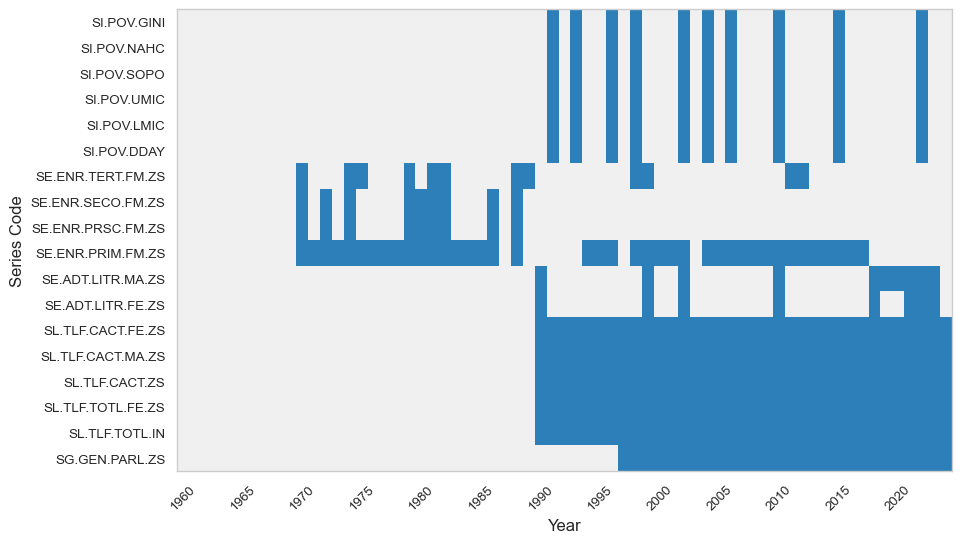

In [7]:
availability, fig, ax = plot_missing_heatmap(
    inequality_clean,
    lookup=inequality_lookup,
)

fig.savefig(
    "../figures/inequality/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)